## 0. CONFIGURATION

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import LabelEncoder

In [2]:
# Set constants
FILE_PATH = "RT_IOT2022.csv"                # path to the raw dataset
ORIGINAL_TARGET = "Attack_type"             # original target column name
TARGET_COLUMN = "Attack_grouped"            # grouped target column name
DOS_SYN_SAMPLE_SIZE = 10000                 # max rows to keep for DOS_SYN_Hping
VARIANCE_THRESHOLD = 0.01                   # drop features with variance below this
CORRELATION_THRESHOLD = 0.90                # drop one from pairs above this
MI_TOP_K = 15                               # how many top features to highlight
RANDOM_STATE = 42
OUTPUT_CSV = "selected_features_report.csv"

## 1. DATA QUALITY CHECKS

In [3]:
# load the dataset
print("=" * 60)
print("Load the dataset")
print("=" * 60)

df = pd.read_csv(FILE_PATH)
print(f"Original shape: {df.shape}")
df.head()

Load the dataset
Original shape: (123117, 85)


,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


Checking the independent features

In [4]:
# Basic info and stats
print("=" * 60)
print("Basic info and stats")
print("=" * 60)

df.info()
df.describe().T

Basic info and stats
<class 'pandas.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  str    
 4   service                   123117 non-null  str    
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio             123117 n

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,123117.0,3.703509e+04,3.045911e+04,0.0,6059.000000,33100.000000,63879.000000,9.465800e+04
id.orig_p,123117.0,3.463926e+04,1.907062e+04,0.0,17702.000000,37221.000000,50971.000000,6.553500e+04
id.resp_p,123117.0,1.014305e+03,5.256372e+03,0.0,21.000000,21.000000,21.000000,6.538900e+04
flow_duration,123117.0,3.809566e+00,1.300054e+02,0.0,0.000001,0.000004,0.000005,2.172834e+04
fwd_pkts_tot,123117.0,2.268826e+00,2.233656e+01,0.0,1.000000,1.000000,1.000000,4.345000e+03
...,...,...,...,...,...,...,...,...
idle.avg,123117.0,1.664985e+06,9.007064e+06,0.0,0.000000,0.000000,0.000000,3.000000e+08
idle.std,123117.0,4.550183e+04,1.091361e+06,0.0,0.000000,0.000000,0.000000,1.208029e+08
fwd_init_window_size,123117.0,6.118905e+03,1.871631e+04,0.0,64.000000,64.000000,64.000000,6.553500e+04
bwd_init_window_size,123117.0,2.739776e+03,1.001885e+04,0.0,0.000000,0.000000,0.000000,6.553500e+04


> Before going further, we decided to drop the first column since it's an index and it's not be relevant to our analysis.

In [5]:
# Drop the unnamed index column and check info again
print("=" * 60)
print("Drop the unnamed index column and check info again")
print("=" * 60)

#Drop the unnamed index column
df = df.drop(columns=["Unnamed: 0"])

#Check the info again after dropping the index column
df.info()

Drop the unnamed index column and check info again
<class 'pandas.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 84 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.orig_p                 123117 non-null  int64  
 1   id.resp_p                 123117 non-null  int64  
 2   proto                     123117 non-null  str    
 3   service                   123117 non-null  str    
 4   flow_duration             123117 non-null  float64
 5   fwd_pkts_tot              123117 non-null  int64  
 6   bwd_pkts_tot              123117 non-null  int64  
 7   fwd_data_pkts_tot         123117 non-null  int64  
 8   bwd_data_pkts_tot         123117 non-null  int64  
 9   fwd_pkts_per_sec          123117 non-null  float64
 10  bwd_pkts_per_sec          123117 non-null  float64
 11  flow_pkts_per_sec         123117 non-null  float64
 12  down_up_ratio             123117 non-null  float64
 13  fwd_

In [6]:
# Missing values and duplicates
print("=" * 60)
print("Missing values and duplicates")
print("=" * 60)

missing_values = df.isnull().sum()[df.isnull().sum() > 0]
if len(missing_values) == 0:
    print("No missing values found in the dataset.")
else:
    print(f"Features with missing values : {list(missing_values.index)}")

#Check for duplicate rows
duplicates = df.duplicated().sum()
if duplicates == 0:
    print("No duplicate rows found in the dataset.")
else:
    print(f"Number of duplicate rows : {duplicates}")



Missing values and duplicates
No missing values found in the dataset.
Number of duplicate rows : 5195


> Since we have duplicates, it's necessary to drop them

In [7]:
# Drop duplicates and check again
print("=" * 60)
print("Drop duplicates and check again")
print("=" * 60)

print(f"Number of duplicate rows (before dropping) : {duplicates}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows (after dropping) : {df.duplicated().sum()}")

Drop duplicates and check again
Number of duplicate rows (before dropping) : 5195
Number of duplicate rows (after dropping) : 0


> Since source ports are usually random values assigned by the operating system, we dropped **id.orig_p** 

In [8]:
# Drop the id.orig_p column and check info again
print("=" * 60)
print("Drop id.orig_p column and check info again")
print("=" * 60)

#Drop the id.orig_p column
df = df.drop(columns=["id.orig_p"])

#Check the info again after dropping the index column
df.info()

Drop id.orig_p column and check info again
<class 'pandas.DataFrame'>
Index: 117922 entries, 0 to 123116
Data columns (total 83 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.resp_p                 117922 non-null  int64  
 1   proto                     117922 non-null  str    
 2   service                   117922 non-null  str    
 3   flow_duration             117922 non-null  float64
 4   fwd_pkts_tot              117922 non-null  int64  
 5   bwd_pkts_tot              117922 non-null  int64  
 6   fwd_data_pkts_tot         117922 non-null  int64  
 7   bwd_data_pkts_tot         117922 non-null  int64  
 8   fwd_pkts_per_sec          117922 non-null  float64
 9   bwd_pkts_per_sec          117922 non-null  float64
 10  flow_pkts_per_sec         117922 non-null  float64
 11  down_up_ratio             117922 non-null  float64
 12  fwd_header_size_tot       117922 non-null  int64  
 13  fwd_header_size_m

In [9]:
# Identify numeric and categorical columns
print("=" * 60)
print("Identify numeric and categorical columns")
print("=" * 60)

categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric features : {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)} -> {categorical_cols}")

Identify numeric and categorical columns
Numeric features : 80
Categorical features: 3 -> ['proto', 'service', 'Attack_type']


C:\Users\alfar\AppData\Local\Temp\ipykernel_43964\4099769900.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


Checking numerical features

In [10]:
# Check for negative values in numeric columns
print("=" * 60)
print("Check for negative values in numeric columns")
print("=" * 60)

negative_counts = (df[numeric_cols] < 0).sum()
negative_cols = negative_counts[negative_counts > 0]
print(f"Columns with negative values: {negative_cols.tolist()}")

Check for negative values in numeric columns
Columns with negative values: []


Checking categorical features

In [11]:
# Show unique values in each categorical column to check for data quality issues.
print("=" * 60)
print("Show unique values in each categorical column")
print("=" * 60)

for col in categorical_cols:
    print(f"Unique values in '{col}': {df[col].unique()}")

Show unique values in each categorical column
Unique values in 'proto': <StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str
Unique values in 'service': <StringArray>
['mqtt', '-', 'http', 'dns', 'ntp', 'ssl', 'dhcp', 'irc', 'ssh', 'radius']
Length: 10, dtype: str
Unique values in 'Attack_type': <StringArray>
[              'MQTT_Publish',                'Thing_Speak',
                 'Wipro_bulb',             'ARP_poisioning',
             'DDOS_Slowloris',              'DOS_SYN_Hping',
 'Metasploit_Brute_Force_SSH',              'NMAP_FIN_SCAN',
          'NMAP_OS_DETECTION',              'NMAP_TCP_scan',
              'NMAP_UDP_SCAN',        'NMAP_XMAS_TREE_SCAN']
Length: 12, dtype: str


> We found that the feature **service** contained the value ‘**-**’. Therefore, we replaced this value with ‘**Unidentified**’

In [12]:
# service: Replace '-' with 'Unidentified' in 'service' column
print("=" * 60)
print("Replace '-' with 'Unidentified' in 'service' column")
print("=" * 60)

df.replace('-', "Unidentified", inplace=True)
print(f"Unique values in 'service' (after replacement): {df['service'].unique()}")

Replace '-' with 'Unidentified' in 'service' column
Unique values in 'service' (after replacement): <StringArray>
[        'mqtt', 'Unidentified',         'http',          'dns',
          'ntp',          'ssl',         'dhcp',          'irc',
          'ssh',       'radius']
Length: 10, dtype: str


Analyzing the target

Display original class distribution
Original class distribution:
Attack_type
DOS_SYN_Hping                 90089
Thing_Speak                    7654
ARP_poisioning                 7625
MQTT_Publish                   4142
NMAP_UDP_SCAN                  2584
NMAP_XMAS_TREE_SCAN            2010
NMAP_OS_DETECTION              2000
NMAP_TCP_scan                  1002
DDOS_Slowloris                  533
Wipro_bulb                      219
Metasploit_Brute_Force_SSH       36
NMAP_FIN_SCAN                    28

Original class proportions(%):
Attack_type
DOS_SYN_Hping                 0.763971
Thing_Speak                   0.064907
ARP_poisioning                0.064661
MQTT_Publish                  0.035125
NMAP_UDP_SCAN                 0.021913
NMAP_XMAS_TREE_SCAN           0.017045
NMAP_OS_DETECTION             0.016960
NMAP_TCP_scan                 0.008497
DDOS_Slowloris                0.004520
Wipro_bulb                    0.001857
Metasploit_Brute_Force_SSH    0.000305
NMAP_FIN_SCAN     

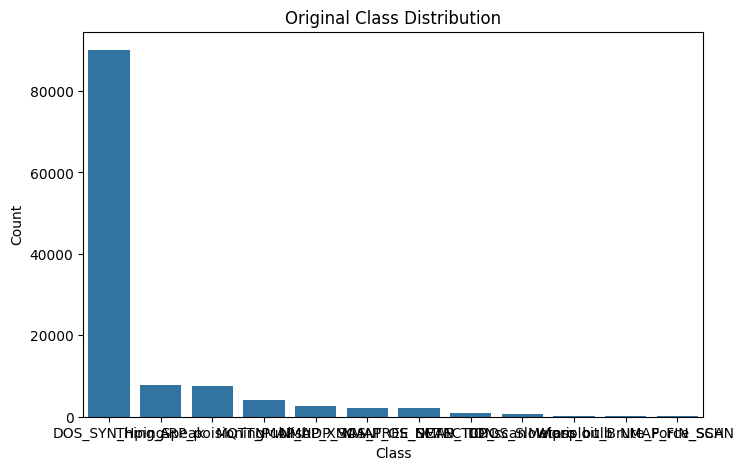

In [13]:
# Display original class distribution
print("=" * 60)
print("Display original class distribution")
print("=" * 60)

print(f"Original class distribution:\n{df[ORIGINAL_TARGET].value_counts().to_string()}\n")
print(f"Original class proportions(%):\n{df[ORIGINAL_TARGET].value_counts(normalize=True).to_string()}\n")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=ORIGINAL_TARGET, order=df[ORIGINAL_TARGET].value_counts().index)
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

> There is a significant imbalance in the values of the target variable. Therefore, we decided to retain 10,000 rows from the DOS_SYN_Hping class, group MQTT_Publish, Thing_Speak, and Wipro_bulb into a single class called NORMAL, group NMAP_FIN_SCAN, NMAP_OS_DETECTION, NMAP_TCP_SCAN, NMAP_UDP_SCAN, and NMAP_XMAS_TREE_SCAN into a single class called NMAP, and remove the minority classes (DDOS_Slowloris and Metasploit_Brute_Force_SSH).

In [14]:
# Preprocessing: downsample, group, and filter
print("=" * 60)
print("Preprocessing : downsample, group, and filter")
print("=" * 60)

# Downsample DOS_SYN_Hping to reduce class imbalance
dos_syn_records = df[df[ORIGINAL_TARGET] == "DOS_SYN_Hping"]
df_dos = dos_syn_records.head(DOS_SYN_SAMPLE_SIZE)
df = pd.concat([df_dos, df[df[ORIGINAL_TARGET] != "DOS_SYN_Hping"]], ignore_index=True)
print(f"After downsampling DOS_SYN_Hping to {DOS_SYN_SAMPLE_SIZE}: {df.shape}")

# Group traffic types into broader categories
Normal_traffic = ["MQTT_Publish", "Thing_Speak", "Wipro_bulb"]
NMAP_traffic = ["NMAP_FIN_SCAN", "NMAP_OS_DETECTION", "NMAP_TCP_scan",
                "NMAP_UDP_SCAN", "NMAP_XMAS_TREE_SCAN"]

df[TARGET_COLUMN] = df[ORIGINAL_TARGET].apply(
    lambda x: "Normal" if x in Normal_traffic
    else ("NMAP" if x in NMAP_traffic else x)
)
print(f"Grouped Normal traffic: {Normal_traffic}")
print(f"Grouped NMAP traffic : {NMAP_traffic}")

# Drop minority classes with too few records
drop_classes = ["DDOS_Slowloris", "Metasploit_Brute_Force_SSH"]
df = df[~df[ORIGINAL_TARGET].isin(drop_classes)]
print(f"Dropped classes: {drop_classes}")

# Drop the original target column (keep only the grouped one)
df = df.drop(columns=[ORIGINAL_TARGET])

Preprocessing : downsample, group, and filter
After downsampling DOS_SYN_Hping to 10000: (37833, 83)
Grouped Normal traffic: ['MQTT_Publish', 'Thing_Speak', 'Wipro_bulb']
Grouped NMAP traffic : ['NMAP_FIN_SCAN', 'NMAP_OS_DETECTION', 'NMAP_TCP_scan', 'NMAP_UDP_SCAN', 'NMAP_XMAS_TREE_SCAN']
Dropped classes: ['DDOS_Slowloris', 'Metasploit_Brute_Force_SSH']


After preprocessing (class distribution)
Final shape: (37264, 83)
Final class distribution:
Attack_grouped
Normal            12015
DOS_SYN_Hping     10000
ARP_poisioning     7625
NMAP               7624

Final proportions:
Attack_grouped
Normal            0.322429
DOS_SYN_Hping     0.268356
ARP_poisioning    0.204621
NMAP              0.204594



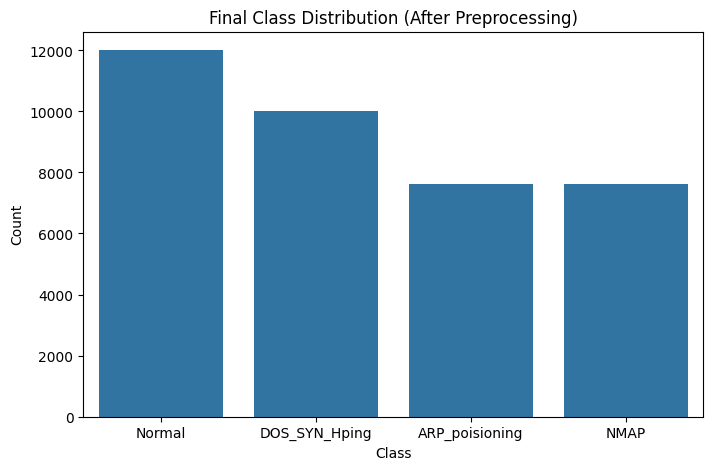

In [15]:
print("=" * 60)
print("After preprocessing (class distribution)")
print("=" * 60)

print(f"Final shape: {df.shape}")
print("Final class distribution:")
print(f"{df[TARGET_COLUMN].value_counts().to_string()}")
print("\nFinal proportions:")
print(f"{df[TARGET_COLUMN].value_counts(normalize=True).to_string()}\n")

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_COLUMN, order=df[TARGET_COLUMN].value_counts().index)
plt.title("Final Class Distribution (After Preprocessing)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

To conclude this section, let's summarize what we have done:
- Drop index column
- Check missing values
- Drop duplicates
- Check negatives in numeric columns
- Check weird values in categorical columns
- Downsize the target class DOS_SYN_Hping to balance the dataset
- Drop minority classes
- Create a new column (Attack_grouped): Group target classes to have a balance dataset
- Drop original target (Attack_type)

## 2. EDA

Categorical

Examining service vs target
Attack_grouped  ARP_poisioning  DOS_SYN_Hping  NMAP  Normal
service                                                    
Unidentified               486          10000  7442     176
dhcp                        11              0     3      14
dns                       5533              0    32    3869
http                       129              0   141    2495
irc                          0              0     0      28
mqtt                         0              0     0    4132
ntp                          7              0     4     104
radius                       0              0     2       0
ssl                       1459              0     0    1197


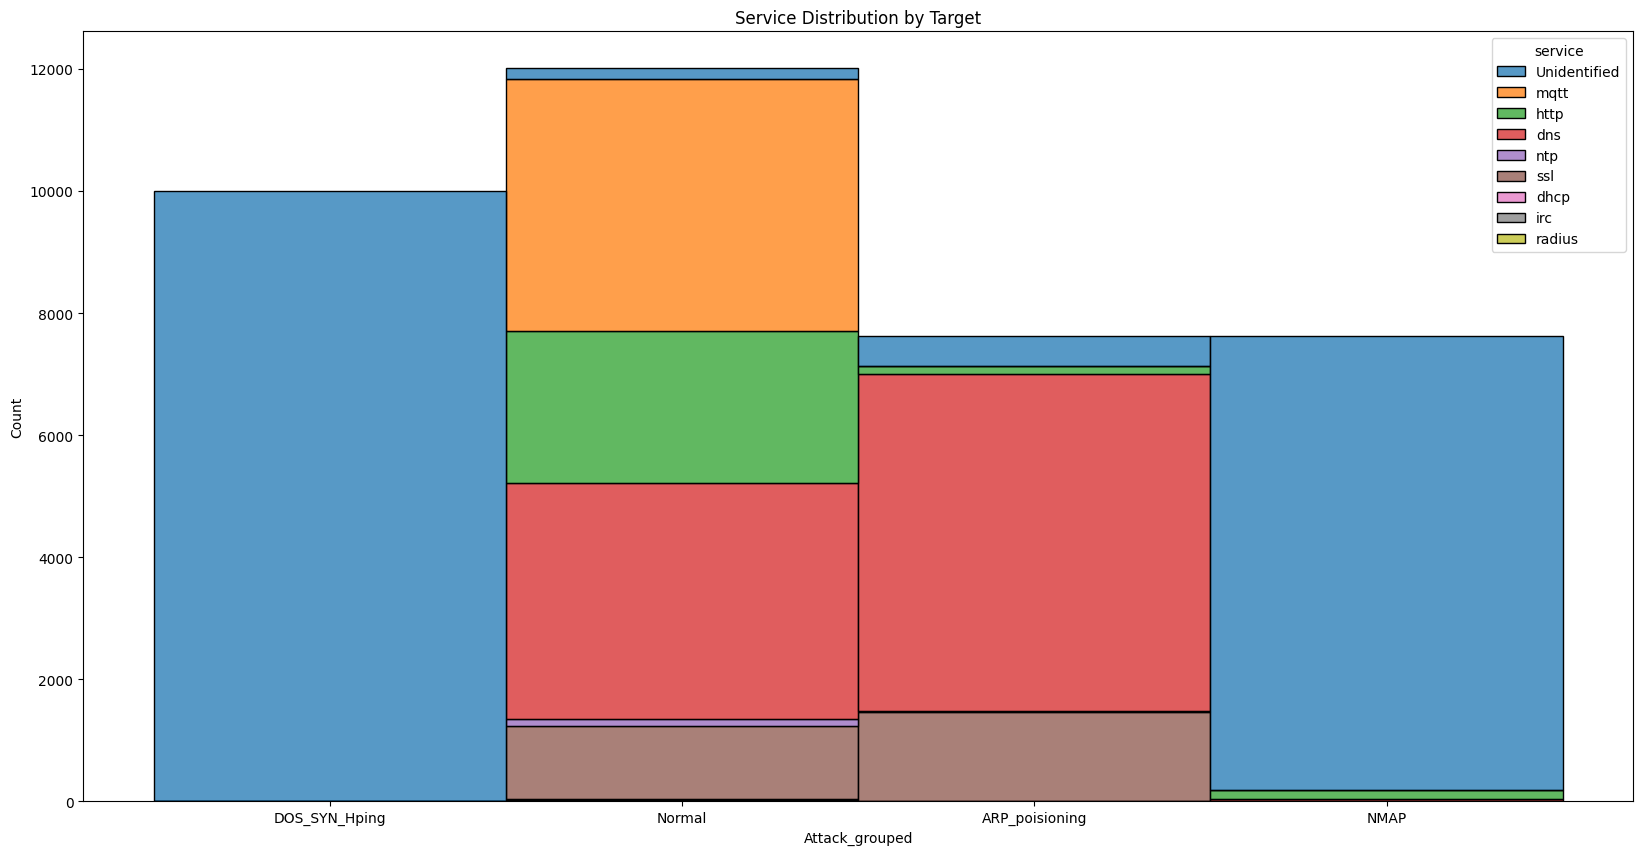

In [16]:
print("=" * 60)
print("Examining service vs target")
print("=" * 60)

# Examine crosstab of service vs target variable to see if there are any patterns that could be useful for modeling.
print(pd.crosstab(df["service"], df[TARGET_COLUMN]))

#Plot service distribution by target class
plt.figure(figsize=(20, 10))
sns.histplot(data=df, x=TARGET_COLUMN, hue="service", multiple="stack", discrete=True)
plt.title("Service Distribution by Target")
plt.xlabel(TARGET_COLUMN)
plt.ylabel("Count")
plt.show()

> This feature is useful for separating some classes. The values **mqtt** and **irc** only appear in **Normal** traffic, so they are very strong indicators of normal behavior. All **DOS_SYN_Hping** rows have the value **Unidentified**, and the values **dns** and **ssl** mostly appear in **ARP_poisioning** and **Normal**, and are rare in the other classes.

Examining proto vs target
Attack_grouped  ARP_poisioning  DOS_SYN_Hping  NMAP  Normal
proto                                                      
icmp                         7              0     2      25
tcp                       1868          10000  5175    7902
udp                       5750              0  2447    4088


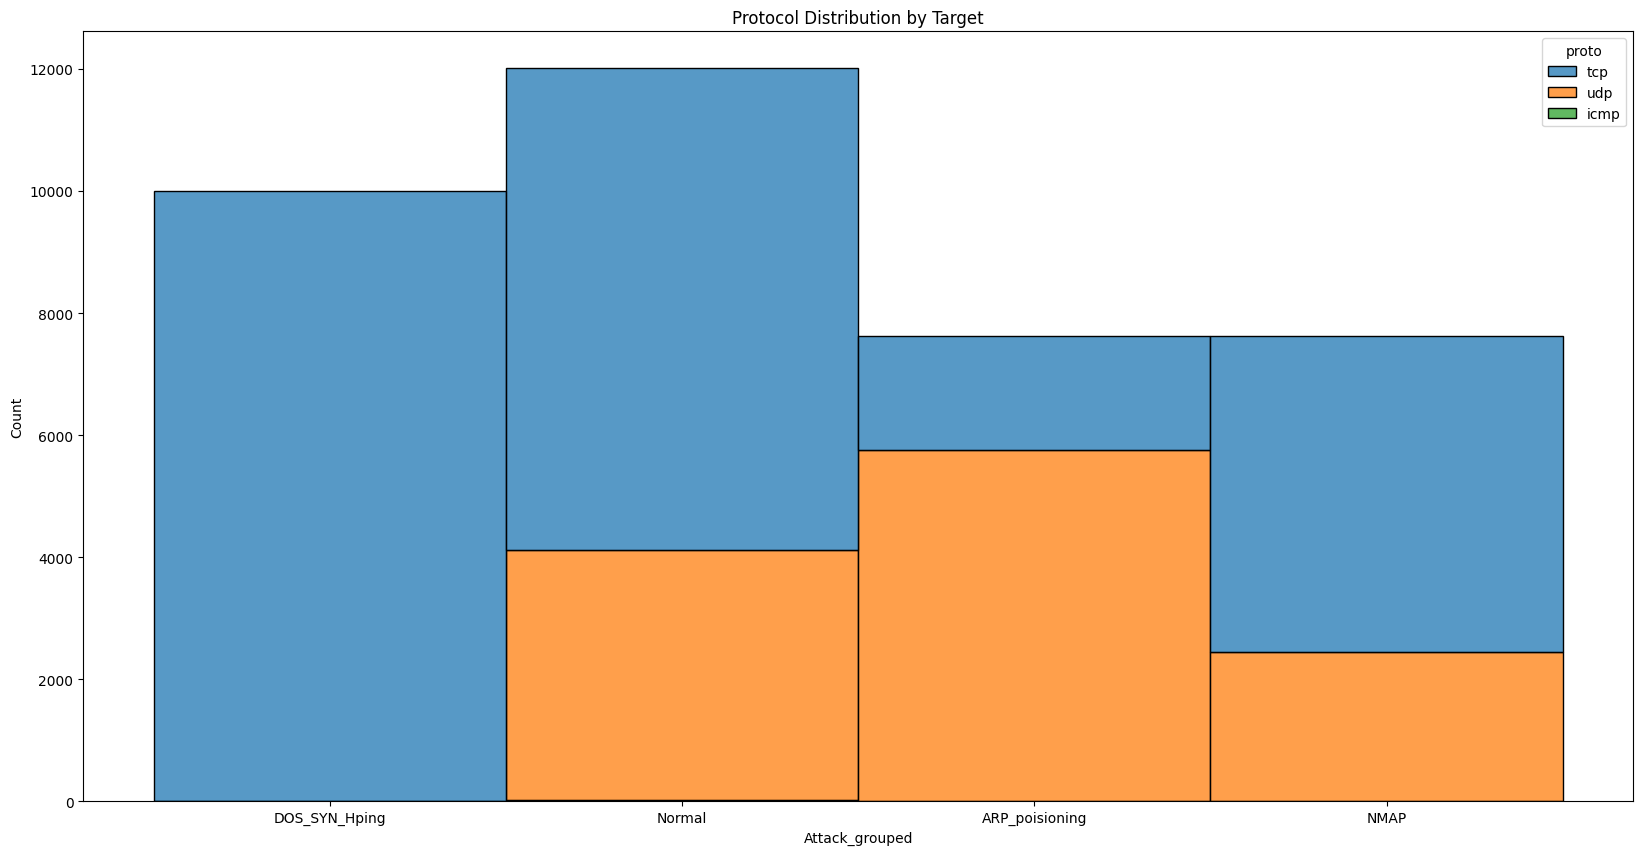

In [17]:
print("=" * 60)
print("Examining proto vs target")
print("=" * 60)

# Examine crosstab of service vs target variable to see if there are any patterns that could be useful for modeling.
print(pd.crosstab(df["proto"], df[TARGET_COLUMN]))

#Plot service distribution by target class
plt.figure(figsize=(20, 10))
sns.histplot(data=df, x=TARGET_COLUMN, hue="proto", multiple="stack", discrete=True)
plt.title("Protocol Distribution by Target")
plt.xlabel(TARGET_COLUMN)
plt.ylabel("Count")
plt.show()

> This feature is helpful mainly for identifying **DOS_SYN_Hping**, since all DOS rows use the tcp protocol. Also, **udp** never appears in DOS traffic, so it helps rule out that class. However, both **tcp** and **udp** are common in **ARP_poisioning, NMAP, and Normal**, so **proto** alone cannot separate those three classes well. The value **icmp** has very few records and does not add much information.

In conclusion, we keep proto because it helps identify DOS traffic, and it complements the service feature. Service is strong for detecting Normal traffic, while proto is strong for detecting DOS attacks.

## 3. FEATURE ENGINEERING

Preparing features and target

In [18]:
print("=" * 60)
print("Preparing features and target")
print("=" * 60)

# Separate features and target
y = df[TARGET_COLUMN]
X = df.drop(columns=[TARGET_COLUMN])

# Identify column types
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric features : {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)} -> {categorical_cols}")

# Encode categorical features for analysis
label_encoders = {}
X_encoded = X.copy()
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

# Encode target
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

Preparing features and target
Numeric features : 80
Categorical features: 2 -> ['proto', 'service']


C:\Users\alfar\AppData\Local\Temp\ipykernel_43964\2704560160.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


Variance Threshold: remove constant/quasi-constant

In [19]:
print("\n" + "=" * 60)
print("Variance Threshold")
print("=" * 60)

selector_var = VarianceThreshold(threshold=VARIANCE_THRESHOLD)
selector_var.fit(X_encoded[numeric_cols])

low_variance_mask = ~selector_var.get_support()
low_variance_cols = [numeric_cols[i] for i, flag in enumerate(low_variance_mask) if flag]

print(f"Threshold: {VARIANCE_THRESHOLD}")
print(f"Features removed ({len(low_variance_cols)}): {low_variance_cols}")

# Keep features that passed the variance check
surviving_numeric = [c for c in numeric_cols if c not in low_variance_cols]
surviving_cols = surviving_numeric + categorical_cols
print(f"Remaining features: {len(surviving_cols)}")


Variance Threshold
Threshold: 0.01
Features removed (3): ['bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count']
Remaining features: 79


> 3 features were removed since their variance was less than or equal to  1%

Pearson Correlation Analysis


Pearson Correlation Analysis
Threshold: 0.9
Highly correlated pairs found: 77
Top correlated pairs:
flow_iat.tot <-> flow_duration : 1.0000
flow_pkts_per_sec <-> bwd_pkts_per_sec : 1.0000
flow_pkts_per_sec <-> fwd_pkts_per_sec : 1.0000
bwd_pkts_per_sec <-> fwd_pkts_per_sec : 0.9999
bwd_bulk_packets <-> bwd_bulk_bytes : 0.9998
idle.max <-> flow_iat.max : 0.9997
flow_iat.tot <-> fwd_iat.tot : 0.9997
fwd_iat.tot <-> flow_duration : 0.9997
flow_iat.max <-> fwd_iat.max : 0.9964
idle.tot <-> flow_duration : 0.9964
Features removed (31): ['active.max', 'bwd_bulk_bytes', 'bwd_data_pkts_tot', 'bwd_header_size_min', 'bwd_header_size_tot', 'bwd_iat.avg', 'bwd_iat.max', 'bwd_pkts_payload.max', 'bwd_pkts_payload.std', 'bwd_pkts_payload.tot', 'bwd_pkts_per_sec', 'bwd_pkts_tot', 'bwd_subflow_pkts', 'flow_ACK_flag_count', 'flow_duration', 'flow_iat.max', 'flow_iat.std', 'flow_iat.tot', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'fwd_bulk_bytes', 'fwd_header_size_max', 'fwd_header_size_min', 'f

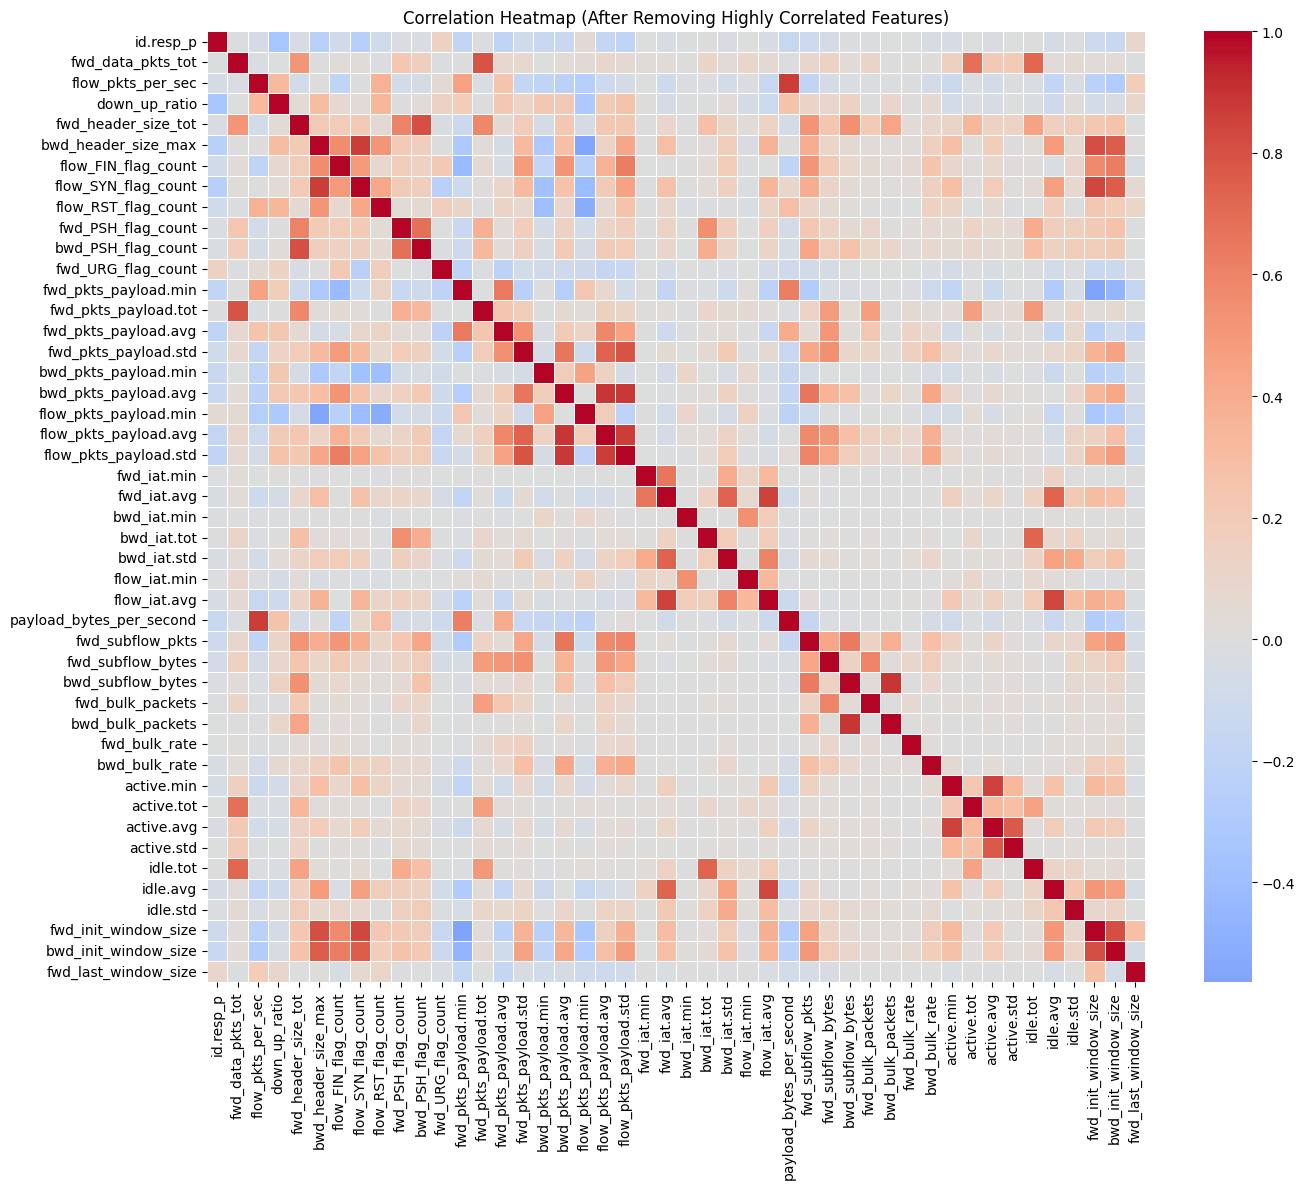

In [20]:
print("\n" + "=" * 60)
print("Pearson Correlation Analysis")
print("=" * 60)

corr_matrix = X_encoded[surviving_numeric].corr().abs()

# Get upper triangle to avoid duplicate pairs
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find pairs exceeding the threshold
high_corr_pairs = []
to_drop_corr = set()

for col in upper_triangle.columns:
    correlated = upper_triangle.index[upper_triangle[col] > CORRELATION_THRESHOLD].tolist()
    for corr_col in correlated:
        high_corr_pairs.append((col, corr_col, corr_matrix.loc[corr_col, col]))
        # Drop the one with lower mutual information (we'll use a simple heuristic:
        # drop the second one in the pair for now)
        to_drop_corr.add(corr_col)

print(f"Threshold: {CORRELATION_THRESHOLD}")
print(f"Highly correlated pairs found: {len(high_corr_pairs)}")
if high_corr_pairs:
    print("Top correlated pairs:")
    sorted_pairs = sorted(high_corr_pairs, key=lambda x: x[2], reverse=True)
    for f1, f2, corr_val in sorted_pairs[:10]:
        print(f"{f1} <-> {f2} : {corr_val:.4f}")

print(f"Features removed ({len(to_drop_corr)}): {sorted(to_drop_corr)}")

surviving_after_corr = [c for c in surviving_numeric if c not in to_drop_corr]
final_candidates = surviving_after_corr + categorical_cols
print(f"Remaining features: {len(final_candidates)}")

# Correlation heatmap (for the surviving features)
plt.figure(figsize=(14, 12))
sns.heatmap(
    X_encoded[surviving_after_corr].corr(),
    cmap="coolwarm", center=0,
    xticklabels=True, yticklabels=True,
    fmt=".1f", linewidths=0.5
)
plt.title("Correlation Heatmap (After Removing Highly Correlated Features)")
plt.tight_layout()
plt.show()

> 31 features were removed since their correlation was greater than or equal to 90%

Mutual Information Ranking


Mutual Information Ranking


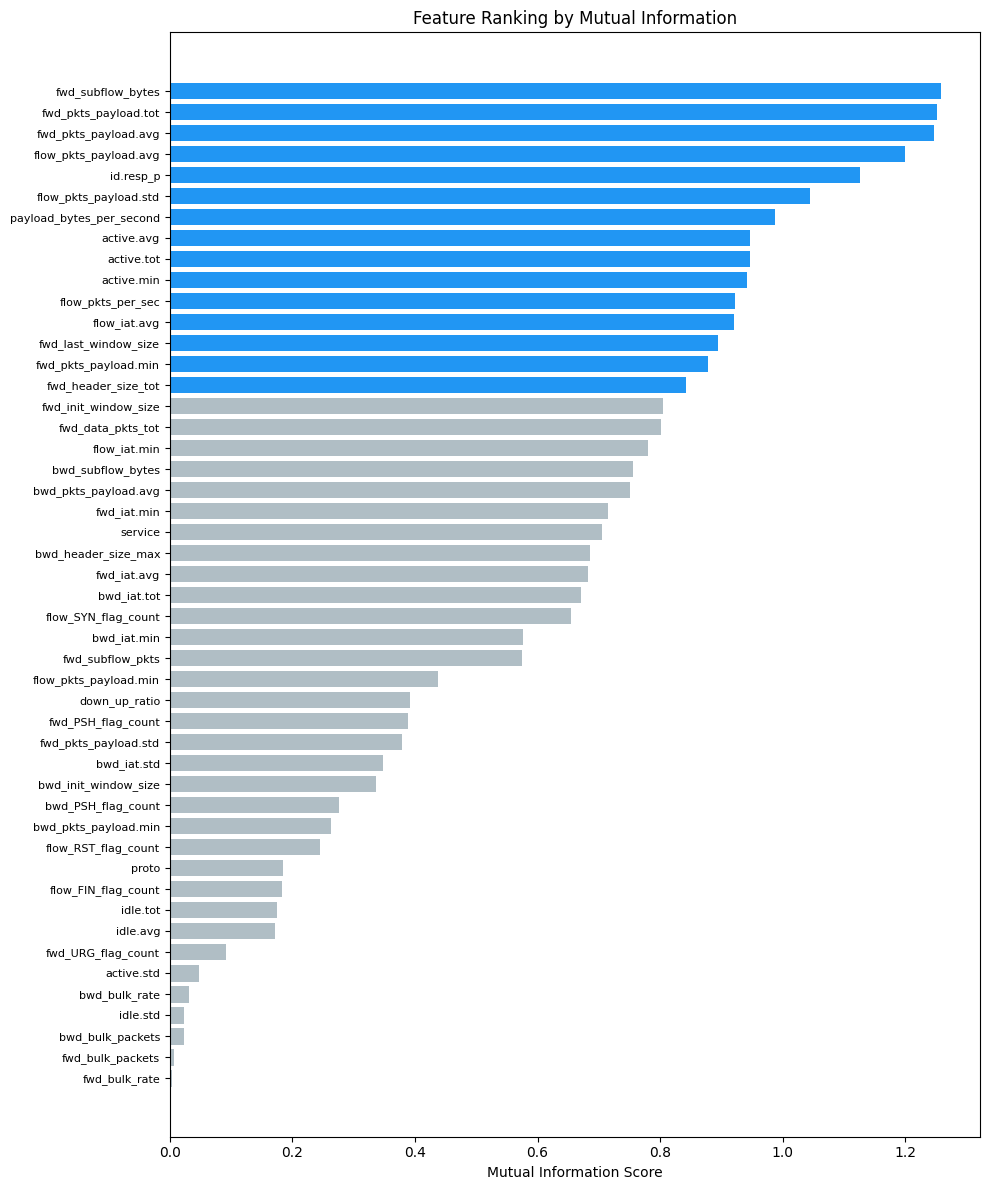

In [21]:
print("\n" + "=" * 60)
print("Mutual Information Ranking")
print("=" * 60)

X_final = X_encoded[final_candidates]

mi_scores = mutual_info_classif(
    X_final, y_encoded,
    discrete_features=[final_candidates.index(c) for c in categorical_cols if c in final_candidates],
    random_state=RANDOM_STATE,
    n_neighbors=5
)

mi_df = pd.DataFrame({
    "feature": final_candidates,
    "mi_score": mi_scores
}).sort_values("mi_score", ascending=False).reset_index(drop=True)

# Plot MI scores
plt.figure(figsize=(10, max(6, len(mi_df) * 0.25)))
colors = ["#2196F3" if i < MI_TOP_K else "#B0BEC5" for i in range(len(mi_df))]
plt.barh(range(len(mi_df)), mi_df["mi_score"].values, color=colors)
plt.yticks(range(len(mi_df)), mi_df["feature"].values, fontsize=8)
plt.xlabel("Mutual Information Score")
plt.title("Feature Ranking by Mutual Information")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

> From this step, we only selected the top 15 features with the highest mutual information scores

Final selected features

In [22]:
print("=" * 60)
print("Summary")
print("=" * 60)

total_original = X.shape[1]
removed_variance = len(low_variance_cols)
removed_corr = len(to_drop_corr)
total_remaining = len(final_candidates)

print(f"Original features           : {total_original}")
print(f"Removed (low variance)      : {removed_variance}")
print(f"Removed (high correlation)  : {removed_corr}")
print(f"Remaining candidates        : {total_remaining}")
print(f"Recommended top-{MI_TOP_K}          : {mi_df['feature'].head(MI_TOP_K).tolist()}")

Summary
Original features           : 82
Removed (low variance)      : 3
Removed (high correlation)  : 31
Remaining candidates        : 48
Recommended top-15          : ['fwd_subflow_bytes', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'flow_pkts_payload.avg', 'id.resp_p', 'flow_pkts_payload.std', 'payload_bytes_per_second', 'active.avg', 'active.tot', 'active.min', 'flow_pkts_per_sec', 'flow_iat.avg', 'fwd_last_window_size', 'fwd_pkts_payload.min', 'fwd_header_size_tot']


In [23]:
# Final selected features 
selected_features = [
    'fwd_subflow_bytes', 
    'fwd_pkts_payload.tot', 
    'fwd_pkts_payload.avg', 
    'flow_pkts_payload.avg', 
    'id.resp_p', 
    'flow_pkts_payload.std', 
    'payload_bytes_per_second', 
    'active.avg', 
    'active.tot', 
    'active.min', 
    'flow_pkts_per_sec', 
    'flow_iat.avg', 
    'fwd_last_window_size', 
    'fwd_pkts_payload.min', 
    'fwd_header_size_tot',
    'service',
    'proto'
]

a.	What is the Pearson correlation coefficient? 
The Pearson correlation coefficient is a number between -1 and 1 that shows how two variables are related.
- 1.0 means they move perfectly together (Positive Correlation).
- -1.0 means when one goes up, the other goes down perfectly (Negative Correlation).
- 0 means there is no relationship at all.  

b.	How important is each attribute for predicting the target (heat map)?
A heatmap uses colors to show which features have the strongest connection to the target. We look for columns that have a high correlation number with the target because those are the most important "clues." If a feature has a score close to 0, it isn't very helpful for predicting the outcome and might be dropped. 

c.	What is k-fold cross-validation?
K-fold cross-validation is a way to make sure our model actually works and didn't just get lucky. We split the data into k number of groups (usually 5 or 10). The computer trains on all the groups except one, tests itself on that last group, and then repeats the process until every group has been the "test" group. We then average the scores to get a more honest accuracy.     

d.	Why is the training dataset 70–80%? Why is the test dataset 20–30%?
We give the model the majority of the data (70-80%) because it needs a lot of examples to study and learn the patterns. We save a smaller portion (20-30%) as a "final exam." Since the model has never seen this test data before, it’s the only way to prove it can actually catch new values in the real world instead of just memorizing the training data.

# 4. MODEL BUILDING 

In [24]:
# Seperate the data in target and features for modeling
X = df[selected_features]
y = df[TARGET_COLUMN]

In [25]:
# Identify numeric and categorical columns in the final selected features
numeric_features = X.select_dtypes("number").columns
categorical_features = X.select_dtypes("object").columns

C:\Users\alfar\AppData\Local\Temp\ipykernel_43964\3287897338.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes("object").columns


In [26]:
# Split the data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

In [27]:
# Create preprocessing pipelines for numeric and categorical features
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# For numeric features
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# For categorical features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first"))
])

# Combine pipelines into a ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

### Logistic Regression

In [28]:
# Import logistic regression model
from sklearn.linear_model import LogisticRegression

# Create a pipeline that combines the preprocessor with the 
# logistic regression model
log_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Fit the model on the training data
log_model.fit(X_train, y_train)

# Make predictions on the test set
log_preds = log_model.predict(X_test)

### Decision Tree

In [29]:
# Import decision tree classifier
from sklearn.tree import DecisionTreeClassifier

# Create a pipeline that combines the preprocessor with the 
# decision tree model
tree_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Fit the model on the training data
tree_model.fit(X_train, y_train)

# Make predictions on the test set
tree_preds = tree_model.predict(X_test)

### Random Forest 

In [30]:
# Import random forest classifier
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline that combines the preprocessor with the 
# random forest model
rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_preds = rf_model.predict(X_test)

### K-Nearest Neighbors

In [31]:
# Import KNN classifier
from sklearn.neighbors import KNeighborsClassifier

# Create a pipeline that combines the preprocessor with the 
# KNN model
knn_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# Fit the model on the training data
knn_model.fit(X_train, y_train)

# Make predictions on the test set
knn_preds = knn_model.predict(X_test)

### Support Vector Machine

In [32]:
# Import SVM classifier
from sklearn.svm import SVC

# Create a pipeline that combines the preprocessor with the 
# SVM classifier model
svm_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", SVC(probability=True))
])

# Fit the model on the training data
svm_model.fit(X_train, y_train)

# Make predictions on the test set
svm_preds = svm_model.predict(X_test)

c.	Provide a brief explanation of how each machine learning algorithm works and why it was chosen for this project.

A Decision Tree Classifier is a supervised, non-parametric learning method used to predict a target variable by learning simple decision rules from the data. It organizes information in a tree-like structure, where each internal node represents a test on a feature, each branch shows the outcome of that test, and each leaf node gives the final prediction or class label. At every step, the algorithm splits the data based on the feature that offers the highest information gain or the lowest Gini impurity, helping it find the most informative split at each level. This model was chosen for the project because it is easy to interpret, requires minimal data preprocessing, and runs efficiently. One of its biggest advantages is transparency - it is possible to clearly trace how each decision was made. It also does not require feature scaling or normalization and works well with both numerical and categorical data. However, a single Decision Tree is prone to overfitting when no depth constraints are applied, which can reduce its ability to generalize to unseen data.

A Random Forest Classifier is an ensemble learning method that builds multiple decision trees during training and combines their outputs to make a final prediction. For classification tasks, it uses a majority voting approach - where the class predicted by most trees becomes the final result. This is built on a technique called bagging (Bootstrap Aggregating), where each tree is trained on a different random subset of the data sampled with replacement. By training each tree on different random subsets of the data and features, the model avoids depending too heavily on any single feature and becomes more balanced overall. This method was selected for the project because of its strong performance, reliability, and ability to highlight feature importance. Compared to a single decision tree, it greatly reduces the chances of overfitting, making it more robust on unseen data. It is also widely known as one of the most accurate out-of-the-box algorithms for structured or tabular datasets. Another advantage is that it can automatically estimate which features contribute the most to predictions, offering useful insights into the data.
 
The K-Nearest Neighbors (KNN) Classifier is a simple, instance-based algorithm often described as a 'lazy learner' because it does not build a model during training. Instead, it stores the entire training dataset and uses it directly when making predictions. When a new data point needs to be classified, the algorithm calculates the distance (typically using Euclidean distance) between that point and all the data points in the training set. It then selects the k closest points, known as neighbors, and assigns the class that appears most frequently among them.
KNN was chosen for this project because of its simplicity and flexibility. It is easy to understand and does not rely on assumptions about how the data is distributed, making it a non-parametric method. It also performs well in multi-class classification problems. However, a known trade-off is that prediction time increases as the dataset grows, since the algorithm must compute distances to every stored point at inference time.
 


d.	List the default hyperparameters used for each algorithm and briefly describe their purpose.

Decision Tree:
- criterion = "gini" - measures the quality of a split using Gini impurity as the default metric
- splitter = "best" - determines how the split at each node is chosen, selecting the best possible split
- max_depth = None - the tree grows until all leaves are pure or contain fewer samples than min_samples_split
- min_samples_split = 2 - defines the minimum number of samples required to split an internal node
- min_samples_leaf = 1 - defines the minimum number of samples required to be at a leaf node

Random Forest:
- n_estimators = 100 - controls the number of trees built in the forest
- criterion = "gini" - measures the quality of splits within each tree using Gini impurity
- max_features = "sqrt" - determines how many features are considered when searching for the best split
- bootstrap = True - the model uses sampling with replacement when creating training subsets for each tree
- min_samples_split = 2 - defines the minimum number of samples required to split an internal node

KNN:
- n_neighbors = 5 - determines how many neighbors are considered when making a prediction
- weights = "uniform" - all neighbors have equal influence on the prediction result
- metric = "minkowski" - defines how distance is measured between data points
- p = 2 - combined with the Minkowski metric, this corresponds to Euclidean distance
- algorithm = "auto" - determines the method used to compute nearest neighbors, letting Scikit-Learn automatically select the most appropriate option based on the data

# 5. EVALUATION 

In [33]:
# Import functions to evaluate model performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, hamming_loss
from sklearn.preprocessing import label_binarize

classes = ['ARP_poisioning', 'DOS_SYN_Hping', 'NMAP', 'Normal']

#define a function to evaluate the model performance using various metrics
def evaluate_model(name, y_true, y_pred, pipeline=None):
    print("Model:", name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    
    # Hamming Loss
    print("Hamming Loss:", round(hamming_loss(y_true, y_pred), 4))
    
    # ROC-AUC — only if pipeline supports predict_proba
    if pipeline is not None and hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_prob    = pipeline.predict_proba(X_test)
        y_test_bin = label_binarize(y_true, classes=classes)
        roc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
        print("ROC-AUC (macro):", round(roc, 4))
    else:
        print("ROC-AUC: Not available for this model")
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("\n")

In [34]:
# Evaluate each model's performance on the test set
evaluate_model("Logistic Regression", y_test, log_preds,  log_model)
evaluate_model("Decision Tree",       y_test, tree_preds, tree_model)
evaluate_model("Random Forest",       y_test, rf_preds,   rf_model)
evaluate_model("KNN",                 y_test, knn_preds,  knn_model)
evaluate_model("SVM",                 y_test, svm_preds,  svm_model)

Model: Logistic Regression
Accuracy: 0.971152556017711
Hamming Loss: 0.0288
ROC-AUC (macro): 0.992
Confusion Matrix:
[[1405    2   12  106]
 [   0 2000    0    0]
 [   9    0 1516    0]
 [  82    1    3 2317]]
Classification Report:
                precision    recall  f1-score   support

ARP_poisioning       0.94      0.92      0.93      1525
 DOS_SYN_Hping       1.00      1.00      1.00      2000
          NMAP       0.99      0.99      0.99      1525
        Normal       0.96      0.96      0.96      2403

      accuracy                           0.97      7453
     macro avg       0.97      0.97      0.97      7453
  weighted avg       0.97      0.97      0.97      7453



Model: Decision Tree
Accuracy: 0.9919495505165705
Hamming Loss: 0.0081
ROC-AUC (macro): 0.9945
Confusion Matrix:
[[1497    0    4   24]
 [   0 2000    0    0]
 [   4    0 1519    2]
 [  21    0    5 2377]]
Classification Report:
                precision    recall  f1-score   support

ARP_poisioning       0.98   

In [70]:
# Compile results into a DataFrame for easier comparison
results = {
    "Logistic Regression": accuracy_score(y_test, log_preds),
    "Decision Tree": accuracy_score(y_test, tree_preds),
    "Random Forest": accuracy_score(y_test, rf_preds),
    "KNN": accuracy_score(y_test, knn_preds),
    "SVM": accuracy_score(y_test, svm_preds)
}

# Create a DataFrame from the results dictionary, sort by accuracy in 
# descending order
pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"]).sort_values("Accuracy", ascending=False)

,Accuracy
Random Forest,0.993694
Decision Tree,0.991950
KNN,0.989132
SVM,0.979874
Logistic Regression,0.971153


> After running the 5 models and analyzing their accuracies, we decided to select Random Forest, Decision Tree, and KNN. Additionally, after reviewing the results and researching further, we identified a limitation in the dataset: all rows for DOS_SYN_Hping were generated by the same tool with the same configuration, making them identical in feature space. As a result, the models learned the hping3 tool signature rather than generalizing SYN flood attack behavior. A more diverse dataset including traffic from multiple attack tools and configurations would be required to evaluate true generalization.

### Accuracy
The percentage of flows correctly classified out of all test flows (7,453 total).
- Random Forest correctly classified 7,406 flows
- Decision Tree correctly classified 7,393 flows
- KNN correctly classified 7,371 flows

All three models perform strongly, with Random Forest being the most accurate.

### Hamming Loss
The fraction of incorrectly predicted labels. Lower is better, 0 is perfect.

- Random Forest misclassified only 0.63% of flows
- Decision Tree misclassified 0.81% of flows
- KNN misclassified 1.09% of flows

In practical terms, for every 1,000 flows analyzed, Random Forest makes only 6 errors, while KNN makes 11.

### ROC-AUC (macro)
Measures how well each model separates the 4 classes regardless of threshold. Ranges from 0.5 (random) to 1.0 (perfect).

- Random Forest: 0.9999 - nearly perfect class separation
- KNN: 0.9984 - excellent separation
- Decision Tree: 0.9945 - very strong separation

All three models score above 0.99, indicating they can reliably distinguish between Normal, NMAP, ARP_poisoning, and DOS_SYN_Hping traffic.

### Precision
Of all flows predicted as a specific class, how many were actually that class. High precision means few false alarms. The model does not incorrectly flag legitimate traffic as an attack.
All three models achieve 0.98-1.00 precision per class, with the exception of ARP_poisoning where precision is slightly lower (0.97–0.98) because some Normal flows are misclassified as ARP_poisoning.

### Recall
Of all actual flows belonging to a class, how many did the model correctly detect. High recall means few missed attacks — critical in a security context.
All three models achieve 0.98-1.00 recall per class. DOS_SYN_Hping achieves perfect recall of 1.00 across all three models — no DOS attack was ever missed.

### Confusion Matrix
Best Model: Random Forest

- DOS_SYN_Hping is perfectly classified (100%) by all three models due to its unique fixed feature signature from the hping3 tool
- ARP_poisoning is consistently the hardest class. Its traffic patterns partially overlap with Normal traffic
- The most common error across all models is confusing ARP_poisoning with Normal traffic, and Normal traffic with ARP_poisoning
- Random Forest is the best overall model across all metrics and is therefore the recommended model for deployment

# 6. HYPERPARAMETER TUNING

In [38]:
from sklearn.model_selection import GridSearchCV

# Define a parameter grid for tuning the random forest model
rf_params = {
    "model__n_estimators":      [100, 200],
    "model__criterion":         ["gini", "entropy"],
    "model__max_features":      ["sqrt", "log2"],
    "model__bootstrap":         [True, False],
    "model__min_samples_split": [2, 5],
}

# Set up GridSearchCV to find the best hyperparameters for the random forest model
rf_search = GridSearchCV(
    rf_model,
    rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
    verbose=1
)

# Fit the GridSearchCV object to the training data to perform the hyperparameter tuning
rf_search.fit(X_train, y_train)

# Print the best parameters and best score from the grid search
print("Best parameters:", rf_search.best_params_)
print("Best CV accuracy:", rf_search.best_score_)

# Evaluate tuned model
rf_tuned_preds = rf_search.predict(X_test)
print("\nTuned Random Forest — Test Accuracy:", accuracy_score(y_test, rf_tuned_preds))
print("\nClassification Report:")
print(classification_report(y_test, rf_tuned_preds))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'model__bootstrap': False, 'model__criterion': 'gini', 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 100}
Best CV accuracy: 0.992888500668581

Tuned Random Forest — Test Accuracy: 0.9939621628874279

Classification Report:
                precision    recall  f1-score   support

ARP_poisioning       0.98      0.99      0.99      1525
 DOS_SYN_Hping       1.00      1.00      1.00      2000
          NMAP       0.99      1.00      1.00      1525
        Normal       1.00      0.99      0.99      2403

      accuracy                           0.99      7453
     macro avg       0.99      0.99      0.99      7453
  weighted avg       0.99      0.99      0.99      7453



In [39]:
# Compare default vs tuned
print("\n" + "="*50)
print("COMPARISON: Default vs Tuned Random Forest")
print("="*50)
print(f"Default accuracy:  {accuracy_score(y_test, rf_preds):.4f}")
print(f"Tuned accuracy:    {accuracy_score(y_test, rf_tuned_preds):.4f}")


COMPARISON: Default vs Tuned Random Forest
Default accuracy:  0.9937
Tuned accuracy:    0.9940


GridSearchCV was applied to Random Forest using 5-fold cross-validation across 32 parameter combinations (160 fits total).

**Parameters tuned:**
- `n_estimators`: [100, 200]
- `criterion`: [gini, entropy]
- `max_features`: [sqrt, log2]
- `bootstrap`: [True, False]
- `min_samples_split`: [2, 5]

**Best parameters found:**
- `n_estimators`: 100
- `criterion`: gini
- `max_features`: sqrt
- `bootstrap`: False
- `min_samples_split`: 5

**Best CV accuracy:** 0.9929

| Model | Test Accuracy |
|---|---|
| Default Random Forest | 99.37% |
| Tuned Random Forest | 99.40% |

Tuning produced a marginal improvement of +0.03%, confirming that the default configuration was already near-optimal for this dataset.

# 7. WEB DEV INTEGRATION

In [71]:
import joblib
import os

os.makedirs("models", exist_ok=True)

In [72]:
joblib.dump(tree_model, "models/decision_tree.pkl")
joblib.dump(rf_model,   "models/random_forest.pkl")
joblib.dump(knn_model,  "models/knn.pkl")

print("All models saved.")

All models saved.


In [4]:
import pandas as pd
import numpy as np
import joblib
import shap
from pathlib import Path

# Load dataset and pipeline
df      = pd.read_csv("clean_dataset.csv")
pipeline = joblib.load("models/knn.pkl")

FEATURE_COLUMNS = [
    'fwd_subflow_bytes', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg',
    'flow_pkts_payload.avg', 'id.resp_p', 'flow_pkts_payload.std',
    'payload_bytes_per_second', 'active.avg', 'active.tot', 'active.min',
    'flow_pkts_per_sec', 'flow_iat.avg', 'fwd_last_window_size',
    'fwd_pkts_payload.min', 'fwd_header_size_tot', 'service', 'proto'
]

# Rename columns to match model input
rename_map = {
    'fwd_pkts_payload.avg': 'fwd_pkts_payload.avg',
    'fwd_pkts_payload.tot': 'fwd_pkts_payload.tot',
    'flow_pkts_payload.avg': 'flow_pkts_payload.avg',
    'id.resp_p': 'id.resp_p',
    'flow_pkts_payload.std': 'flow_pkts_payload.std',
    'flow_iat.avg': 'flow_iat.avg',
    'fwd_pkts_payload.min': 'fwd_pkts_payload.min',
    'active.avg': 'active.avg',
    'active.tot': 'active.tot',
    'active.min': 'active.min',
}

X = df[FEATURE_COLUMNS]

# Transform using preprocessor
preprocessor = pipeline.named_steps["preprocess"]
X_transformed = preprocessor.transform(X)

# Save a sample of 100 rows as background
sample = shap.sample(X_transformed, 100)
Path("data").mkdir(exist_ok=True)
np.save("data/background_sample.npy", sample)
print("Background saved!")

c:\Users\alfar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Background saved!
